In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

df = pd.read_csv('breast_cancer.csv')

print("--- Dataset Preview ---")
display(df.head())

print("\n--- Dataset Target Class Distribution ---")

if 'diagnosis' in df.columns:
    print(df['diagnosis'].value_counts())

--- Dataset Preview ---


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



--- Dataset Target Class Distribution ---
diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
# Handles target variable mapping if it contains text like 'M' and 'B'
if 'diagnosis' in df.columns:
    df['target'] = df['diagnosis'].map({'M': 1, 'B': 0})
    X = df.drop(columns=['diagnosis', 'target'])
    y = df['target']
else:
    # Fallback if the dataset columns have different names
    X = df.iloc[:, :-1]  # All columns except last
    y = df.iloc[:, -1]   # Last column as target

# Drops completely useless columns like 'id' or unnamed trailing columns if they exist
if 'id' in X.columns:
    X = X.drop(columns=['id'])
X = X.loc[:, ~X.columns.str.contains('^Unnamed')]

# 2. Split into Train-Test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features (Mean=0, Variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and standardized!")

Data successfully split and standardized!


In [9]:
# 3. Fit a Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict default classes (using the standard 0.5 threshold)
y_pred = model.predict(X_test_scaled)
# Get raw probabilities for metric calculations (ROC-AUC)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Model training complete.")

Model training complete.


--- Confusion Matrix ---
[[71  1]
 [ 3 39]]

--- Classification Report (Precision, Recall, F1-Score) ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



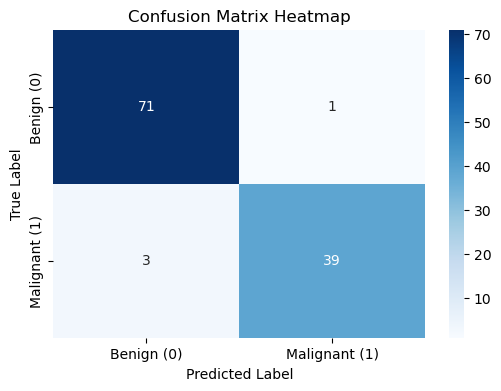

In [10]:
# 4. Evaluate with confusion matrix, precision, recall
cm = confusion_matrix(y_test, y_pred)

print("--- Confusion Matrix ---")
print(cm)

print("\n--- Classification Report (Precision, Recall, F1-Score) ---")
print(classification_report(y_test, y_pred))

# Plot the confusion matrix cleanly using Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

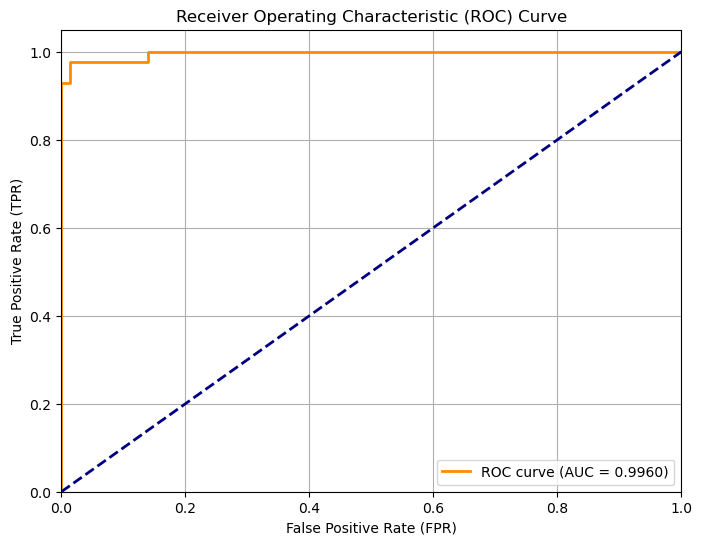

In [11]:
# Calculate ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)

# Compute ROC curve coordinates
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

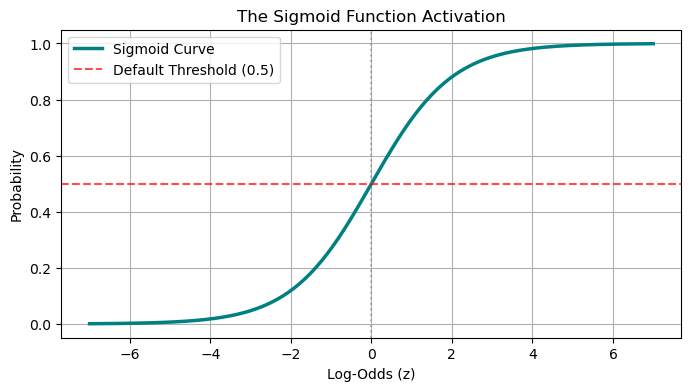

--- Classification Report with Tuned Threshold (0.3) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        72
           1       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [12]:
# 5. Define and plot the Sigmoid Function to show the math visually
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-7, 7, 200)
plt.figure(figsize=(8, 4))
plt.plot(z_values, sigmoid(z_values), color='teal', linewidth=2.5, label='Sigmoid Curve')
plt.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Default Threshold (0.5)')
plt.axvline(0, color='gray', linestyle=':', alpha=0.5)
plt.title('The Sigmoid Function Activation')
plt.xlabel('Log-Odds (z)')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()

# Example: Tuning the classification threshold down to 0.3 to catch more True Positives
custom_threshold = 0.3
y_pred_custom = (y_prob >= custom_threshold).astype(int)

print(f"--- Classification Report with Tuned Threshold ({custom_threshold}) ---")
print(classification_report(y_test, y_pred_custom))